# Deconvolve Chromatin Bins for CLB2

In this notebook, we will be refactoring the creation of the H matrix for the RG1 model. For Yulong's dataset, we have alpha factor arrested cells that go through recovery. We want this recovery period to incorporate the first G1, so the initial branch will be: Recovery - postG1. The calcH needs to be updated to reflect that change.

Goal:
- Refactor the creation of the H matrix
- We need to make changes to add the RG1 logic (merge R and G1 for the first c for {0, 0}

Steps:
1. Plot the growth curve to better understand the existing calc H function

In [248]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [249]:
from src.config import load_yl_replicate2_rg1_config, \
    load_xg_gene_expression_config
from src.model import Model

gene_name = 'CLB2'

# We will load the configuration and model for the gene.
# Note this is still for the gene expression configuration.
# We are most interested in the H matrix.
config = load_yl_replicate2_rg1_config()
model = Model(config, gene_name, 0.004)
print("The shape of the convolution kernel matrix, H is: ", model.H.shape)

The shape of the convolution kernel matrix, H is:  (14, 226)


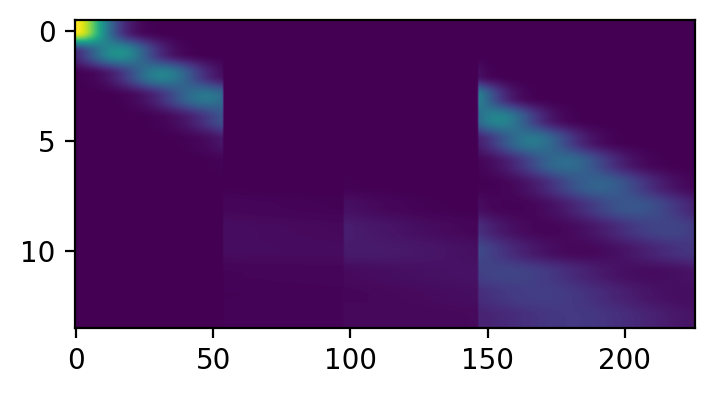

In [250]:
plt.figure(figsize=(4, 2))
plt.imshow(model.H, aspect='auto')

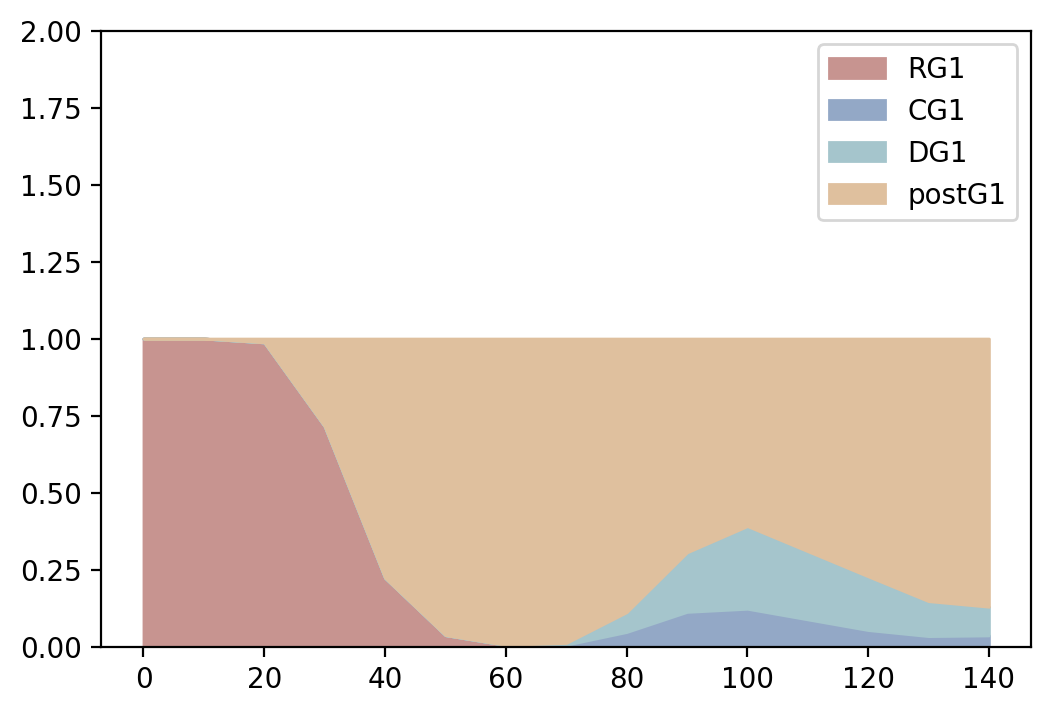

In [251]:
from cc_src.plot_helpers import plot_H_as_growth_curve
plot_H_as_growth_curve(model)

In [252]:
# Let's try and reproduce the growth curves as written in java.

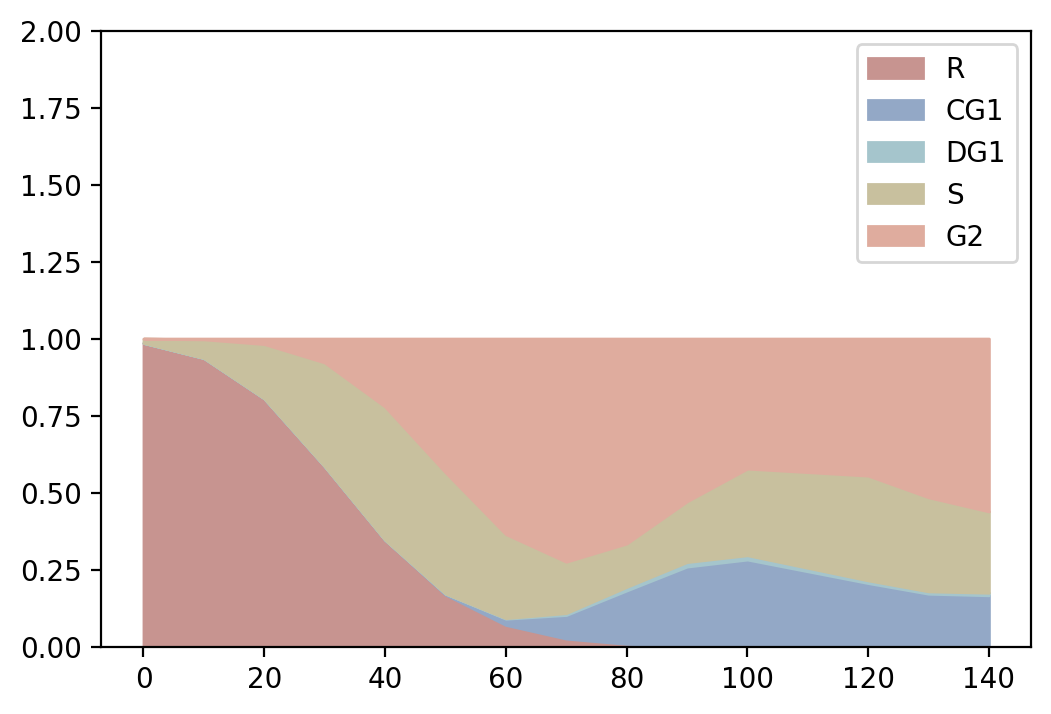

In [253]:
# Porting the mass at time point functions from Java reproduces the growth curves we expect.

from cc_src.model_mass_calculator import MassCalculator

mass_calc = MassCalculator()
sub_mass_df = mass_calc.compute_proportions_all_times(model.config.WT1_TIMEPOINTS)
mass_calc.plot_subinterval_mass_port()

In [254]:
# Now, we will need to translate how the columns are generated in H.